# Hướng Dẫn Giải Thích Chi Tiết: `src/scripts/run_pipeline.py`

Notebook này phân tích cấu trúc, công dụng và cách hoạt động của tệp `src/scripts/run_pipeline.py` - Runner chính dùng để huấn luyện độc lập hoặc huấn luyện gộp các mô hình Machine Learning (XGBoost) và Deep Learning (Transformer) cho các mã cổ phiếu trong Watchlist.

---

## 🔍 1. Tổng Quan Về Pipeline Huấn Luyện

Trong pipeline huấn luyện ngoại tuyến (`offline training`), chúng ta thực hiện các khâu quan trọng:
1. **Định cấu hình Root Path:** Sử dụng đường dẫn tuyệt đối giúp chạy từ bất kỳ thư mục làm việc nào.
2. **Cố định Random Seed:** Đảm bảo kết quả huấn luyện mô hình có thể tái lập.
3. **Huấn luyện độc lập (Individual Training):** Huấn luyện mô hình riêng cho từng mã cổ phiếu (`VNM.VN`, `GOOGL`, `META`) để đạt độ chính xác tối ưu.
4. **Huấn luyện gộp (Global Training):** Phương án huấn luyện một mô hình chung trên toàn bộ tập dữ liệu đa mã.
5. **Đánh giá sai số (Evaluation):** Tính toán chỉ số RMSE, MAE và MAPE (Mean Absolute Percentage Error).
6. **Trực quan hóa kết quả:** Vẽ và lưu đồ thị thực tế vs dự đoán vào thư mục `reports/figures/`.
7. **Lưu trữ mô hình:** Lưu trữ các mô hình `.pkl`, `.keras` và các scalers vào thư mục `models/`.

In [1]:
import sys
import os

# Thêm thư mục gốc vào đường dẫn hệ thống để import src
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print(f"Thư mục gốc của dự án: {ROOT_DIR}")

Thư mục gốc của dự án: C:\Users\ACER\Documents


## ⚙️ 2. Các hàm bổ trợ quan trọng

### Hàm Đánh Giá Sai Số `evaluate_predictions`
Hàm này tính toán:
- **RMSE (Root Mean Squared Error):** Phạt các sai số lớn mạnh hơn.
- **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình dễ hiểu.
- **MAPE:** Tỷ lệ phần trăm sai lệch tương đối so với giá thực tế.

In [2]:
import numpy as np
from src.data_loader import format_vn

def evaluate_dummy(y_true, y_pred, model_name):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"=== KẾT QUẢ MÔ HÌNH {model_name.upper()} ===")
    print(f"❌ Sai số RMSE: {format_vn(rmse)} VNĐ")
    print(f"🎯 Sai số MAE : {format_vn(mae)} VNĐ (Lệch trung bình: {mape:.2f}%)\n")
    return rmse, mae, mape

y_true = np.array([65000, 66000, 65500])
y_pred = np.array([64800, 66200, 65100])
evaluate_dummy(y_true, y_pred, "Demo Model")

=== KẾT QUẢ MÔ HÌNH DEMO MODEL ===
❌ Sai số RMSE: 282,84 VNĐ
🎯 Sai số MAE : 266,67 VNĐ (Lệch trung bình: 0.41%)



(np.float64(282.842712474619),
 np.float64(266.6666666666667),
 np.float64(0.40713654454112463))

### Hàm Lưu Dự Báo Vào File Log `log_prediction_to_file`
Ghi lại kết quả dự báo chi tiết của XGBoost và Transformer, kèm theo các khoảng an toàn biến động (tính dựa trên ATR) và mức độ rủi ro vào file `reports/figures/predictions_history.txt`.

In [3]:
results_dir = os.path.join(ROOT_DIR, "results")
log_path = os.path.join(results_dir, "predictions_history.txt")

if os.path.exists(log_path):
    print(f"Tìm thấy file log lịch sử dự đoán tại: {log_path}")
    print("Xem 5 dòng cuối cùng:")
    with open(log_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[-10:]:
            print(line.strip())

## 🧠 3. Cấu hình học tập Learning Rate và Callbacks
Để huấn luyện mạng Neural Transformer sâu không bị overfit và hội tụ trơn tru, pipeline sử dụng:
1. **EarlyStopping:** Dừng sớm nếu lỗi validation không giảm sau 25 epochs.
2. **ReduceLROnPlateau:** Giảm một nửa tốc độ học nếu lỗi validation chững lại sau 7 epochs.
3. **LearningRateScheduler:** Áp dụng thuật toán **Cosine Decay** làm giảm dần tốc độ học theo đồ thị hình cos, giúp mô hình ổn định cực tốt ở các epochs cuối cùng.

### ⚙️ 3.1 Cải tiến nạp Siêu tham số An toàn (Fallback Parameters)
Khi nạp mô hình, nếu cấu hình tối ưu của Optuna (`best_transformer_params.json` hoặc các bản sao của từng mã như `best_transformer_params_VNM.VN.json`) bị thiếu hoặc lỗi, hệ thống sẽ tự động chuyển sang bộ tham số mặc định an toàn (`d_model=128`, `num_heads=8`, `dropout_rate=0.3`, `learning_rate=1e-4`, `batch_size=64`) giúp hệ thống tiếp tục chạy huấn luyện hoặc dự báo mà không bị dừng đột ngột.

### 📂 3.2 Lưu trữ mô hình theo phiên bản (Model Versioning)
Khi huấn luyện thành công, hệ thống tự động tạo chuỗi nhãn thời gian dạng `_YYYYMMDD_HHMM` (ví dụ: `20260528_2030`) để lưu vết lịch sử mô hình phục vụ cho việc theo dõi, đồng thời lưu đè lên file tên chuẩn `latest` (ví dụ: `transformer_model_VNM.VN.keras`) giúp API backend luôn tải được mô hình mới nhất.

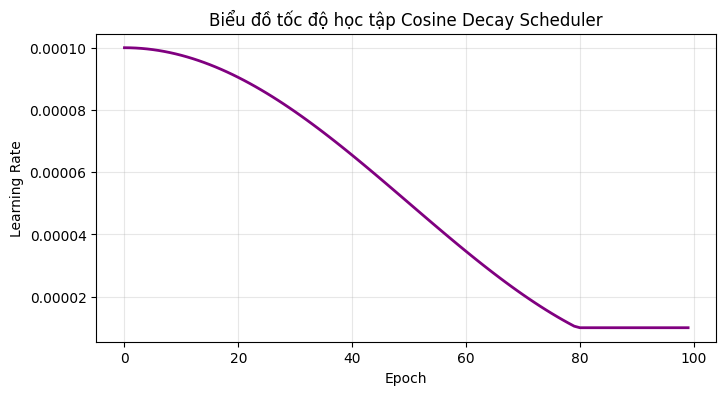

In [4]:
import math
import matplotlib.pyplot as plt

def cosine_decay(epoch):
    initial_lrate = 1e-4
    epochs = 100
    cos_outer = math.pi * epoch / epochs
    lrate = initial_lrate * 0.5 * (1.0 + math.cos(cos_outer))
    return max(lrate, 1e-5)

epochs = range(100)
lr_values = [cosine_decay(e) for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, lr_values, color='purple', linewidth=2)
plt.title('Biểu đồ tốc độ học tập Cosine Decay Scheduler')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.show()

## 🎯 4. Chạy huấn luyện và lưu trữ các file Artifacts
Khi chạy `main.py` từ console:
```bash
python src/scripts/run_pipeline.py
```
Hệ thống sẽ:
1. Tải và chuẩn bị dữ liệu cho `VNM.VN`, `GOOGL`, `META`.
2. Tiến hành chia tập Train/Test theo trình tự thời gian (Chronological Split) với tỷ lệ 80/20.
3. Huấn luyện XGBoost trên tập phẳng, Transformer trên tập 3D.
4. Đánh giá sai số và vẽ đồ thị lưu vào `reports/figures/model_battle_result_{ticker}.png`.
5. Lưu các file mô hình vào `models/` dưới tên ví dụ: `xgboost_model_VNM.VN.pkl` và `transformer_model_VNM.VN.keras`.